In [1]:
import requests
import pandas as pd

# 1. Definiamo i parametri per la nostra chiamata API
url = "https://archive-api.open-meteo.com/v1/archive"
parametri = {
    "latitude": 45.46,      # Latitudine di Milano
    "longitude": 9.19,      # Longitudine di Milano
    "start_date": "2023-01-01",
    "end_date": "2023-12-31",
    "daily": ["temperature_2m_max", "temperature_2m_min", "precipitation_sum"],
    "timezone": "Europe/Berlin"
}

# 2. Facciamo la chiamata API
print("Scaricamento dati in corso...")
risposta = requests.get(url, params=parametri)

# 3. Controlliamo che sia andata a buon fine
if risposta.status_code == 200:
    print("Dati scaricati con successo!\n")

    # Estraiamo il JSON (i dati grezzi)
    dati_grezzi = risposta.json()

    # I dati giornalieri sono dentro la chiave 'daily'
    dati_giornalieri = dati_grezzi['daily']

    # 4. Trasformiamo i dati in un DataFrame pandas (una tabella)
    df = pd.DataFrame(dati_giornalieri)

    # Mostriamo le prime 5 righe
    print(df.head())

else:
    print(f"Errore nella chiamata. Codice di stato: {risposta.status_code}")

Scaricamento dati in corso...
Dati scaricati con successo!

         time  temperature_2m_max  temperature_2m_min  precipitation_sum
0  2023-01-01                 8.6                 7.2                4.4
1  2023-01-02                 9.5                 7.5                3.6
2  2023-01-03                10.0                 8.0               13.5
3  2023-01-04                11.3                 5.5                0.0
4  2023-01-05                12.7                 5.4                0.0


In [2]:
import requests
import pandas as pd
import time # Ci serve per mettere in pausa lo script

# 1. Creiamo un "dizionario" con le città e le loro coordinate
citta = {
    "Milano": {"lat": 45.46, "lon": 9.19},
    "Roma": {"lat": 41.90, "lon": 12.49},
    "Napoli": {"lat": 40.85, "lon": 14.26}
}

url = "https://archive-api.open-meteo.com/v1/archive"
tutti_i_dati = [] # Una lista vuota che farà da "contenitore" per i nostri pezzetti di dati

print("Inizio il download. Potrebbe volerci qualche secondo...")

# 2. Iniziamo il ciclo: per ogni città nel dizionario...
for nome_citta, coordinate in citta.items():
    print(f"Scaricando i dati per {nome_citta}...")

    parametri = {
        "latitude": coordinate["lat"],
        "longitude": coordinate["lon"],
        "start_date": "2019-01-01", # Abbiamo ampliato a 5 anni!
        "end_date": "2023-12-31",
        "daily": ["temperature_2m_max", "temperature_2m_min", "precipitation_sum"],
        "timezone": "Europe/Berlin"
    }

    risposta = requests.get(url, params=parametri)

    if risposta.status_code == 200:
        dati_grezzi = risposta.json()

        # Creiamo il DataFrame temporaneo per questa singola città
        df_temp = pd.DataFrame(dati_grezzi['daily'])

        # 3. IL PASSAGGIO CHIAVE: Aggiungiamo la colonna con il nome della città
        # Altrimenti, una volta uniti i dati, non sapremmo distinguerli!
        df_temp['citta'] = nome_citta

        # Aggiungiamo questo DataFrame alla nostra lista contenitore
        tutti_i_dati.append(df_temp)

        # Mettiamo in pausa lo script per 1 secondo.
        # È buona educazione verso i server dell'API non bombardarli di richieste.
        time.sleep(1)
    else:
        print(f"Errore nello scaricare {nome_citta}. Codice: {risposta.status_code}")

# 4. Uniamo tutti i "pezzetti" in un unico grande DataFrame
df_completo = pd.concat(tutti_i_dati, ignore_index=True)

print("\nEstrazione completata!")
print(f"Il nostro dataset ora ha {df_completo.shape[0]} righe e {df_completo.shape[1]} colonne.\n")

# Invece di .head() usiamo .sample(5) per vedere 5 righe prese a caso
print(df_completo.sample(5))

Inizio il download. Potrebbe volerci qualche secondo...
Scaricando i dati per Milano...
Scaricando i dati per Roma...
Scaricando i dati per Napoli...

Estrazione completata!
Il nostro dataset ora ha 5478 righe e 5 colonne.

            time  temperature_2m_max  temperature_2m_min  precipitation_sum  \
4232  2020-08-03                29.9                21.3                0.0   
4396  2021-01-14                13.2                 2.3                2.7   
5304  2023-07-11                31.3                22.8                0.0   
1661  2023-07-20                31.4                21.8                0.3   
1639  2023-06-28                30.4                20.8                0.0   

       citta  
4232  Napoli  
4396  Napoli  
5304  Napoli  
1661  Milano  
1639  Milano  


In [3]:
# Creiamo una copia del dataset originale per lavorare in sicurezza (è una buona pratica!)
df_pulito = df_completo.copy()

# 1. Rinominiamo le colonne per renderle più semplici
df_pulito = df_pulito.rename(columns={
    'time': 'data',
    'temperature_2m_max': 'temp_max',
    'temperature_2m_min': 'temp_min',
    'precipitation_sum': 'precipitazioni_mm'
})

# 2. Convertiamo la colonna 'data' da semplice testo a un formato "Data" (Datetime)
# Questo ci permetterà di ordinare e filtrare per mesi/anni molto facilmente
df_pulito['data'] = pd.to_datetime(df_pulito['data'])

# 3. Feature Engineering: Creiamo nuove informazioni!
# Calcoliamo la temperatura media giornaliera
df_pulito['temp_media'] = (df_pulito['temp_max'] + df_pulito['temp_min']) / 2

# Estraiamo Anno e Mese dalla data e li mettiamo in due nuove colonne
df_pulito['anno'] = df_pulito['data'].dt.year
df_pulito['mese'] = df_pulito['data'].dt.month

# 4. Controllo qualità: verifichiamo i valori nulli (mancanti)
print("Ci sono valori mancanti (nulli) nel nostro dataset?")
print(df_pulito.isnull().sum())
print("-" * 30)

# 5. Mostriamo le informazioni del nuovo DataFrame
print("Struttura del nuovo dataset:")
df_pulito.info()

print("\nEcco le prime 5 righe pulite:")
print(df_pulito.head())

Ci sono valori mancanti (nulli) nel nostro dataset?
data                 0
temp_max             0
temp_min             0
precipitazioni_mm    0
citta                0
temp_media           0
anno                 0
mese                 0
dtype: int64
------------------------------
Struttura del nuovo dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5478 entries, 0 to 5477
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   data               5478 non-null   datetime64[ns]
 1   temp_max           5478 non-null   float64       
 2   temp_min           5478 non-null   float64       
 3   precipitazioni_mm  5478 non-null   float64       
 4   citta              5478 non-null   object        
 5   temp_media         5478 non-null   float64       
 6   anno               5478 non-null   int32         
 7   mese               5478 non-null   int32         
dtypes: datetime64[ns](1), float64(

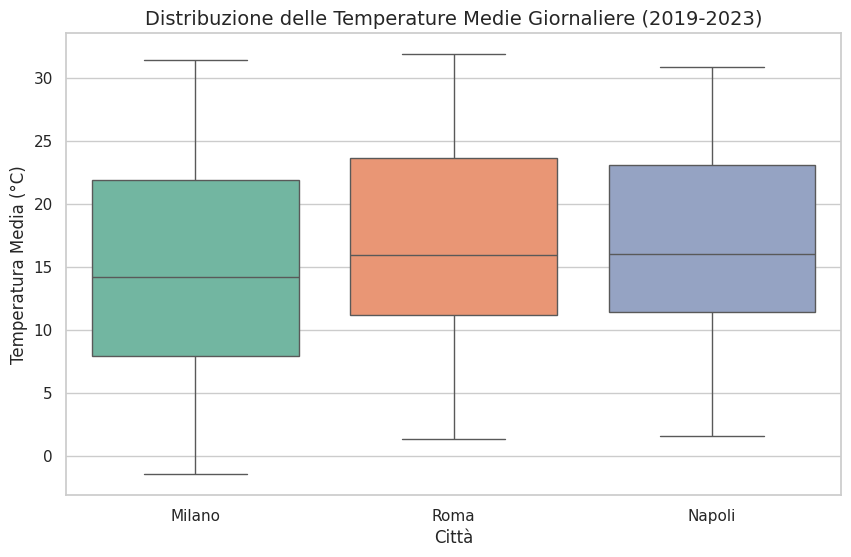

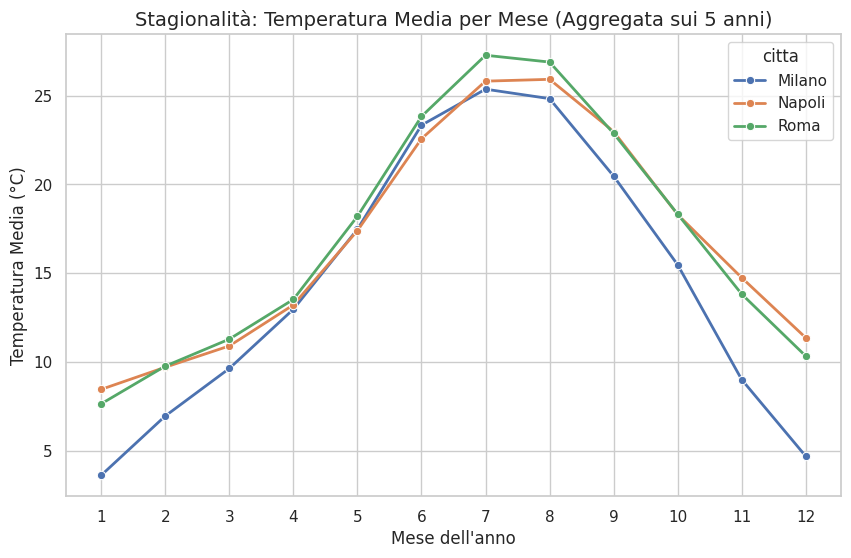

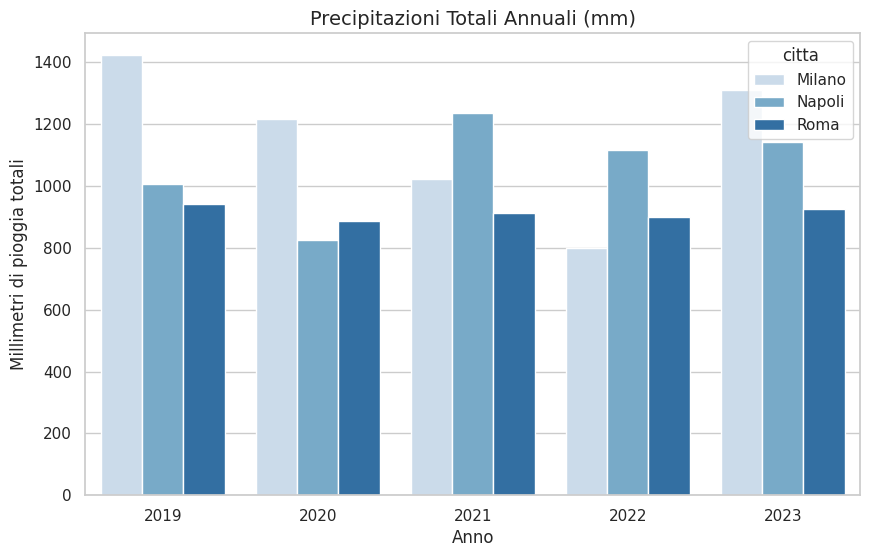

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Impostiamo uno stile elegante per i grafici
sns.set_theme(style="whitegrid")

# ==========================================
# GRAFICO 1: Chi ha il clima più mite? (Boxplot)
# ==========================================
plt.figure(figsize=(10, 6))
sns.boxplot(x='citta', y='temp_media', data=df_pulito, hue='citta', palette='Set2', legend=False)
plt.title('Distribuzione delle Temperature Medie Giornaliere (2019-2023)', fontsize=14)
plt.ylabel('Temperatura Media (°C)')
plt.xlabel('Città')
plt.show()

# ==========================================
# GRAFICO 2: Come cambia la temperatura nei vari mesi? (Lineplot)
# ==========================================
# Prima dobbiamo calcolare la media delle temperature per ogni mese e per ogni città
andamento_mensile = df_pulito.groupby(['mese', 'citta'])['temp_media'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='mese', y='temp_media', hue='citta', data=andamento_mensile, marker='o', linewidth=2)
plt.title('Stagionalità: Temperatura Media per Mese (Aggregata sui 5 anni)', fontsize=14)
plt.xlabel('Mese dell\'anno')
plt.ylabel('Temperatura Media (°C)')
# Forziamo l'asse X a mostrare i numeri da 1 a 12
plt.xticks(range(1, 13))
plt.show()

# ==========================================
# GRAFICO 3: Qual è stata la città più piovosa anno per anno? (Barplot)
# ==========================================
# Sommiamo le precipitazioni per ogni anno e per ogni città
pioggia_annuale = df_pulito.groupby(['anno', 'citta'])['precipitazioni_mm'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='anno', y='precipitazioni_mm', hue='citta', data=pioggia_annuale, palette='Blues')
plt.title('Precipitazioni Totali Annuali (mm)', fontsize=14)
plt.xlabel('Anno')
plt.ylabel('Millimetri di pioggia totali')
plt.show()